In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/3
    print("準備完了！このまま下のセルを実行できます。")

# 3.2 バイアス-バリアンス分解 (The Bias-Variance Decomposition)

本ノートブックでは、教師あり学習における汎化誤差の振る舞いを理解するための最も根本的な理論的枠組みである**バイアス-バリアンス分解 (Bias-Variance Decomposition)** を扱います。
PRML 3.2節の理論展開を導出し、教科書の代表的な実験である **Figure 3.5（正則化パラメータとモデルのばらつき）** および **Figure 3.6（バイアス・バリアンス・テスト誤差のトレードオフ曲線）** を100個のデータセットによるモンテカルロシミュレーションによって忠実に完全再現します。

## 3.2.1 理論的導出 (Theoretical Formulation)

二乗損失関数 $L(t, y(\mathbf{x})) = \{y(\mathbf{x}) - t\}^2$ の下での期待二乗損失は、第1.5.5節より以下のように分解されます：
$$ \mathbb{E}[L] = \int \{y(\mathbf{x}) - h(\mathbf{x})\}^2 p(\mathbf{x}) d\mathbf{x} + \int \{h(\mathbf{x}) - t\}^2 p(\mathbf{x}, t) d\mathbf{x} dt $$
ここで
$$ h(\mathbf{x}) = \mathbb{E}[t | \mathbf{x}] = \int t p(t | \mathbf{x}) dt $$
は条件付き期待値（最適な回帰関数）です。
右辺第2項はデータそのものが持つ除去不可能なノイズ（分散）であり、モデル $y(\mathbf{x})$ に依存しません。
したがって、モデル選択の目的は第1項 $\int \{y(\mathbf{x}) - h(\mathbf{x})\}^2 p(\mathbf{x}) d\mathbf{x}$ を最小化することです。

### データセット集合 $\mathcal{D}$ に関する平均
特定サイズ $N$ のデータセット $\mathcal{D}$ に基づいて学習された予測関数を $y(\mathbf{x}; \mathcal{D})$ と表します。
データセット $\mathcal{D}$ 自体のサンプリングのばらつきについて考えるため、$\mathcal{D}$ に関するアンサンブル平均を
$$ \mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})] $$
と定義します。
被積分関数に $\mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})]$ を足し引きして展開します：
$$ \{y(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\}^2 = \left\{ y(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})] + \mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})] - h(\mathbf{x}) \right\}^2 $$
両辺の $\mathcal{D}$ に関する期待値をとると、交差項
$$ 2 \mathbb{E}_{\mathcal{D}}\left[ (y(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})]) (\mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})) \right] $$
において、第2因子は $\mathcal{D}$ に依存しない定数であるため、第1因子の期待値 $\mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})]] = 0$ により**厳密に 0** になります。

したがって、
$$ \mathbb{E}_{\mathcal{D}}\left[ \{y(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\}^2 \right] = \underbrace{\{\mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\}^2}_{(\mathrm{bias})^2} + \underbrace{\mathbb{E}_{\mathcal{D}}\left[ \{y(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[y(\mathbf{x}; \mathcal{D})]\}^2 \right]}_{\mathrm{variance}} $$
入力空間全体で積分すると：
$$ \text{期待損失} = (\text{バイアス})^2 + \text{バリアンス} + \text{ノイズ} $$
- **$(\mathrm{bias})^2$**: 無限個のデータセットで学習したモデルの「平均的な予測」が真の関数 $h(\mathbf{x})$ からどれだけずれているか（表現力の不足、アンダーフィッティング）。
- **$\mathrm{variance}$**: 学習データセットの偶然の抽出によって、個々のモデル $y(\mathbf{x}; \mathcal{D})$ が平均からどれだけ変動するか（過剰適合のしやすさ、オーバーフィッティング）。

Plot saved to: result/fig3_5_bias_variance_fits.png


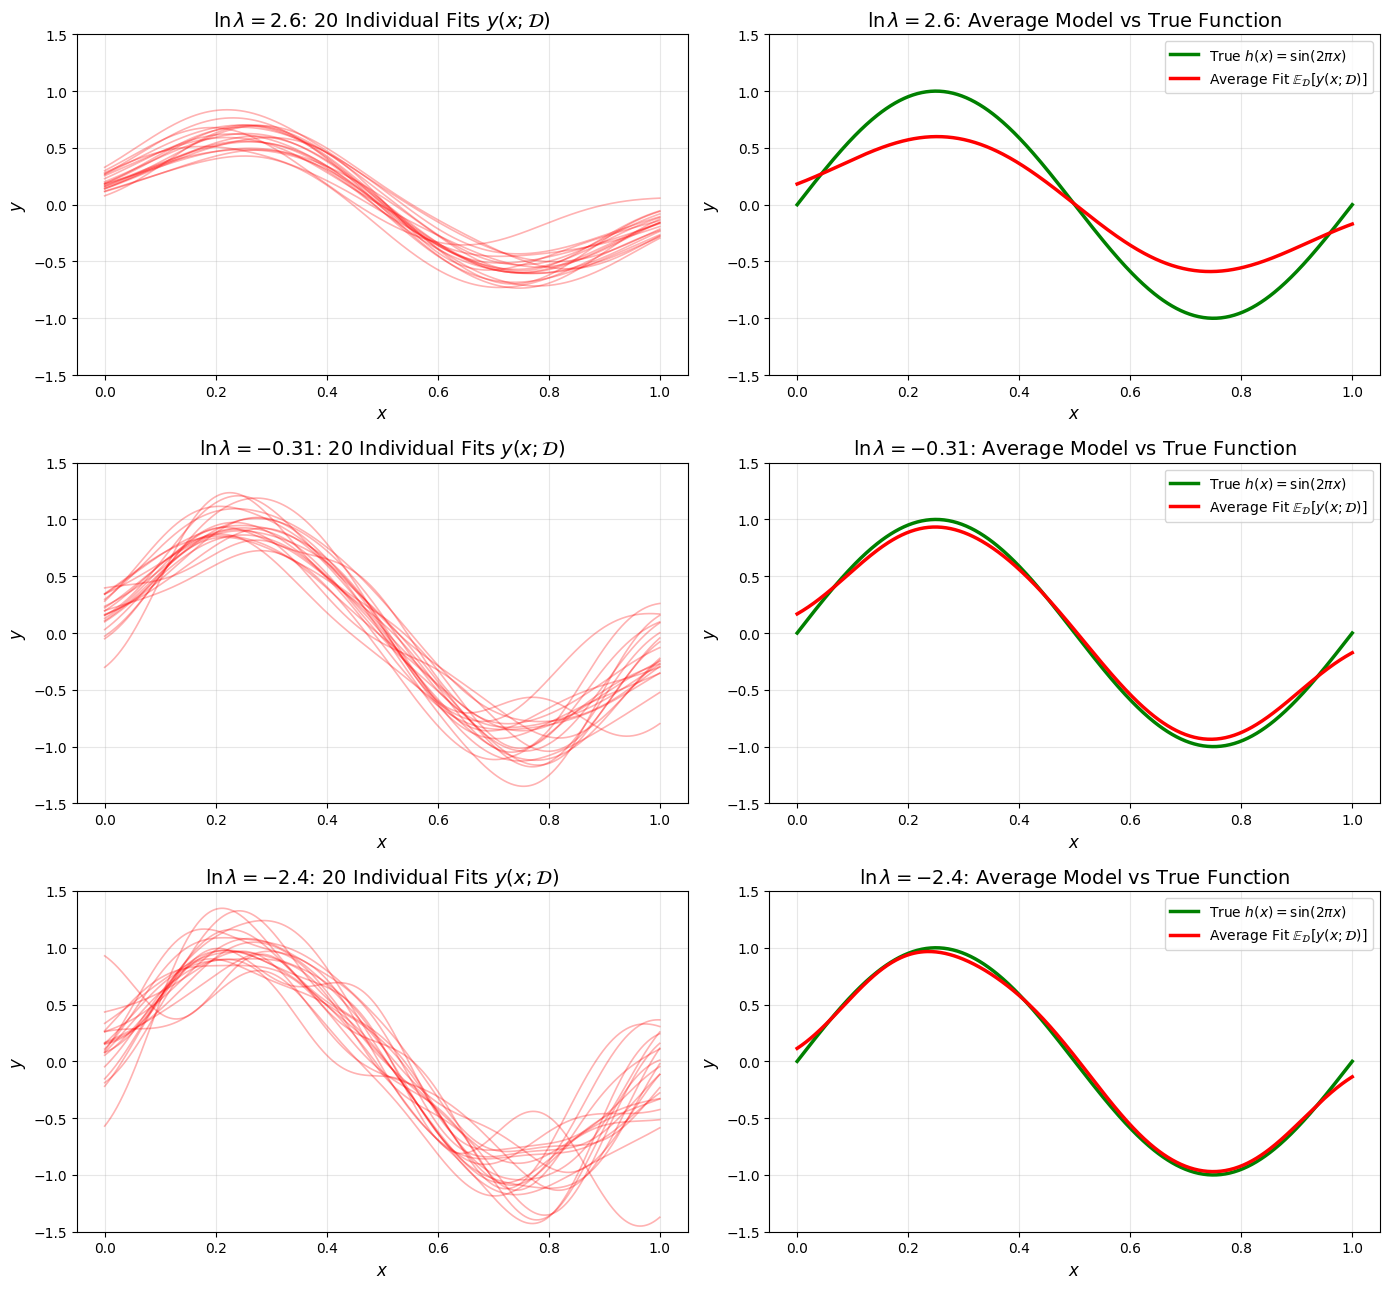

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.regression_utils import GaussianBasis, RidgeRegression
setup_style()

np.random.seed(42)

# 実験設定 (PRML 3.2節)
# 真の関数 h(x) = sin(2 * pi * x)
def true_h(x):
    return np.sin(2 * np.pi * x)

L = 100   # データセットの個数
N = 25    # 各データセットのデータ点数
sigma_noise = 0.3 # ノイズの標準偏差

# ガウス基底関数: M=24 個、間隔 1/(M-1), scale s = 0.1
M = 24
centers = np.linspace(0, 1, M)
scale = 0.1
basis = GaussianBasis(centers=centers, scale=scale)

# 評価用の高密度点
x_test = np.linspace(0, 1, 500)
Phi_test = basis(x_test)
h_test = true_h(x_test)

# L 個の独立なデータセットを生成
datasets = []
for _ in range(L):
    x_d = np.random.uniform(0, 1, N)
    t_d = true_h(x_d) + np.random.normal(0, sigma_noise, N)
    datasets.append((x_d, t_d))

# 3つの正則化係数: ln(lambda) = 2.6 (強), -0.31 (中), -2.4 (弱)
ln_lambdas = [2.6, -0.31, -2.4]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for row_idx, ln_lam in enumerate(ln_lambdas):
    lam = np.exp(ln_lam)
    y_preds = []
    
    for x_d, t_d in datasets:
        Phi_d = basis(x_d)
        model = RidgeRegression(alpha=lam).fit(Phi_d, t_d)
        y_pred = model.predict(Phi_test)
        y_preds.append(y_pred)
        
    y_preds = np.array(y_preds) # (L, len(x_test))
    mean_y = np.mean(y_preds, axis=0) # E_D[y(x; D)]
    
    # 左列: 20本の個別フィッティング曲線
    ax_left = axes[row_idx, 0]
    for i in range(20):
        ax_left.plot(x_test, y_preds[i], 'r-', alpha=0.3, lw=1.2)
    ax_left.set_ylim(-1.5, 1.5)
    ax_left.set_title(rf'$\ln \lambda = {ln_lam}$: 20 Individual Fits $y(x; \mathcal{{D}})$')
    ax_left.set_xlabel('$x$')
    ax_left.set_ylabel('$y$')
    ax_left.grid(True, alpha=0.3)
    
    # 右列: 平均予測関数 E_D[y] と 真の関数 h(x)
    ax_right = axes[row_idx, 1]
    ax_right.plot(x_test, h_test, 'g-', lw=2.5, label=r'True $h(x) = \sin(2\pi x)$')
    ax_right.plot(x_test, mean_y, 'r-', lw=2.5, label=r'Average Fit $\mathbb{E}_{\mathcal{D}}[y(x; \mathcal{D})]$')
    ax_right.set_ylim(-1.5, 1.5)
    ax_right.set_title(rf'$\ln \lambda = {ln_lam}$: Average Model vs True Function')
    ax_right.set_xlabel('$x$')
    ax_right.set_ylabel('$y$')
    ax_right.legend()
    ax_right.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_5_bias_variance_fits.png')
plt.show()

## 3.2.2 バイアス・バリアンス・テスト誤差のトレードオフ曲線 (PRML Figure 3.6)

正則化係数 $\ln \lambda$ を $-5$ から $+3$ まで連続的に変化させ、以下の量を $x$ の評価点全体で平均して算出します：
- **$(\mathrm{bias})^2$**: $\frac{1}{K} \sum_{k=1}^K \{\bar{y}(x_k) - h(x_k)\}^2$
- **$\mathrm{variance}$**: $\frac{1}{K} \sum_{k=1}^K \frac{1}{L} \sum_{l=1}^L \{y^{(l)}(x_k) - \bar{y}(x_k)\}^2$
- **$(\mathrm{bias})^2 + \mathrm{variance}$**: 2つの和
- **テスト誤差**: $\frac{1}{K L} \sum_{l=1}^L \sum_{k=1}^K \{y^{(l)}(x_k) - t_k^{(l)}\}^2$ （ノイズ分散 $\sigma^2$ が加わったもの）

Plot saved to: result/fig3_6_bias_variance_tradeoff.png


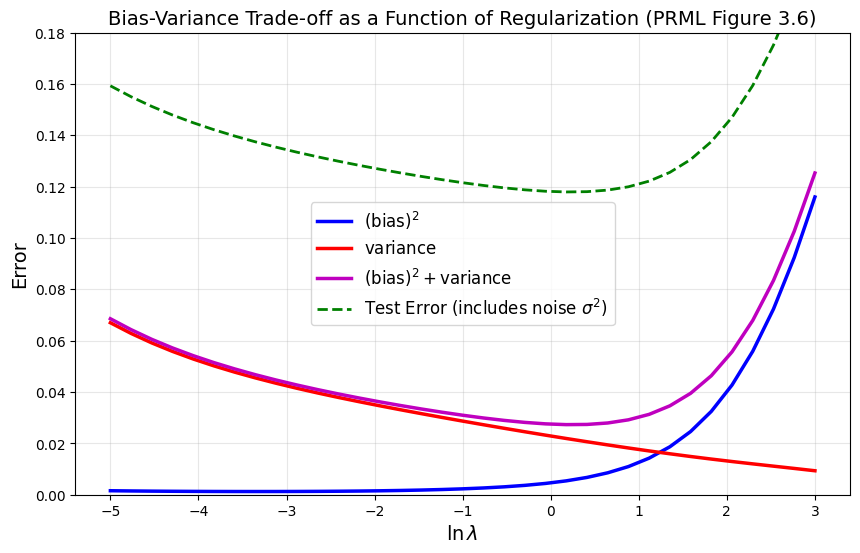

In [2]:
# PRML Figure 3.6 の完全再現
ln_lam_grid = np.linspace(-5, 3, 35)

bias_sq_list = []
var_list = []
test_err_list = []

# 各データセットに対するテスト目標値 (ノイズ付き)
test_targets = [h_test + np.random.normal(0, sigma_noise, len(x_test)) for _ in range(L)]

for ln_lam in ln_lam_grid:
    lam = np.exp(ln_lam)
    y_preds = []
    
    for x_d, t_d in datasets:
        Phi_d = basis(x_d)
        model = RidgeRegression(alpha=lam).fit(Phi_d, t_d)
        y_pred = model.predict(Phi_test)
        y_preds.append(y_pred)
        
    y_preds = np.array(y_preds) # (L, K)
    mean_y = np.mean(y_preds, axis=0) # (K,)
    
    # (bias)^2 = mean over x of (mean_y - h_test)^2
    bias_sq = np.mean((mean_y - h_test)**2)
    
    # variance = mean over x and L of (y_preds - mean_y)^2
    var = np.mean(np.var(y_preds, axis=0))
    
    # test error = mean over L and x of (y_preds - test_target)^2
    test_err = np.mean([(y_preds[l] - test_targets[l])**2 for l in range(L)])
    
    bias_sq_list.append(bias_sq)
    var_list.append(var)
    test_err_list.append(test_err)

bias_sq_arr = np.array(bias_sq_list)
var_arr = np.array(var_list)
sum_bias_var = bias_sq_arr + var_arr

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ln_lam_grid, bias_sq_arr, 'b-', lw=2.5, label=r'$(\mathrm{bias})^2$')
ax.plot(ln_lam_grid, var_arr, 'r-', lw=2.5, label=r'$\mathrm{variance}$')
ax.plot(ln_lam_grid, sum_bias_var, 'm-', lw=2.5, label=r'$(\mathrm{bias})^2 + \mathrm{variance}$')
ax.plot(ln_lam_grid, test_err_list, 'g--', lw=2, label=r'Test Error (includes noise $\sigma^2$)')

ax.set_xlabel(r'$\ln \lambda$', fontsize=14)
ax.set_ylabel('Error', fontsize=14)
ax.set_title('Bias-Variance Trade-off as a Function of Regularization (PRML Figure 3.6)', fontsize=14)
ax.set_ylim(0, 0.18)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig3_6_bias_variance_tradeoff.png')
plt.show()

### 考察と結論
- $\ln \lambda$ が大きい（正則化が強い）とき：モデルは単純化され、データセットによる変動（バリアンス）は極めて小さいですが、真の関数を捉えきれず**バイアス二乗**が急増します。
- $\ln \lambda$ が小さい（正則化が弱い）とき：平均関数 $\mathbb{E}[y]$ は真の関数に極めて近いため**バイアス二乗はほぼゼロ**になりますが、個々のモデルがノイズに過剰適合するため**バリアンス**が極めて大きくなります。
- 最適な汎化性能は、$(	ext{bias})^2$ と $	ext{variance}$ の和が最小となる $\ln \lambda pprox -0.3$ 付近で達成されます。